In [ ]:
include("MiniCollectiveSpins.jl")
include("Functions_time_evol_boxes.jl")
using PyPlot
using Statistics
using JLD2
using OrdinaryDiffEq

### Define the system

In [2]:
# Nbr of particles
N_list = [2:2:10;]
r = 100
d0_lb = 5e-10 # Minimum distance between the atoms (lower boundary) in m
λ = 421e-9
γ = 32.7e6 # In Hz
Ω_RO = 1e7 # Taken from Barbut arXiv:2412.02541v1

# Quantization axis along z
e = [0, 0, 1.]

# Normalisation
d0_lb = d0_lb / λ
Ω_RO = Ω_RO / γ
γ = 1.

t_end = 1e2

window_t, window_var = 2, 4
threshold_box = 1e-5; # Time over which the boxes are computed

# Plots of the time evolution

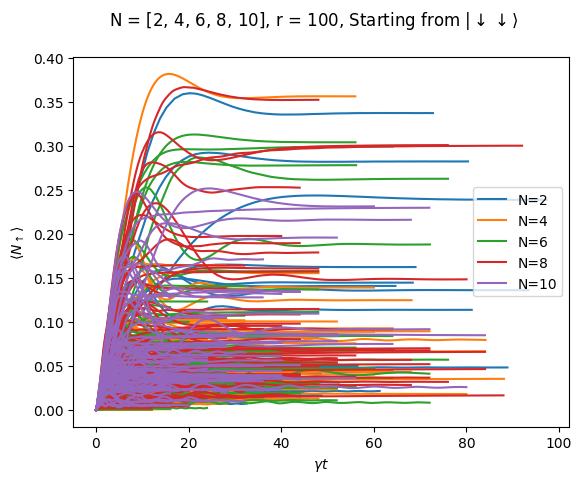

In [3]:
fig, ax = subplots()
list_t_N, popup_t_N, nbr_error_t_N, sol_t_N = [], [], [], []

for (i, N) in enumerate(N_list)
    line = []
    @load "solutions/sol_N_$(N)_r_$(r).jld2" sol_tasks
    list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    push!(list_t_N, list_t), push!(popup_t_N, popup_t), push!(nbr_error_t_N, nbr_error), push!(sol_t_N, sol_t)
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t[j], popup_t[j], label="N=$(N_list[i])") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t[j], popup_t[j], color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  N_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N_list, r = $r, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

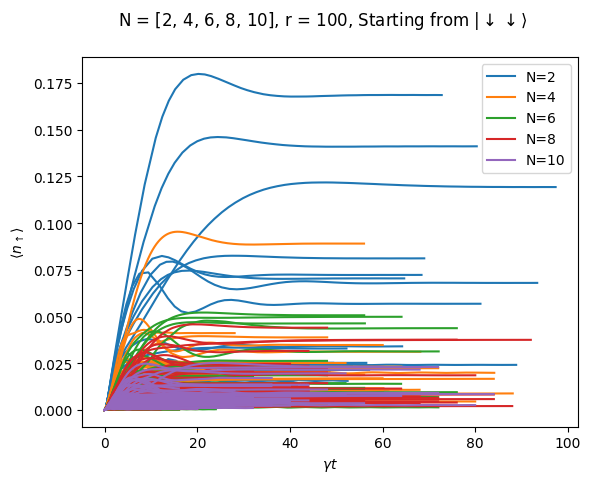

In [4]:
close("all")
fig, ax = subplots()

for (i, N) in enumerate(N_list)
    line = []
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] ./ N_list[i], label="N=$(N_list[i])") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t_N[i][j], popup_t_N[i][j] ./ N_list[i], color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N_list, r = $r, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

# Mean of the SS

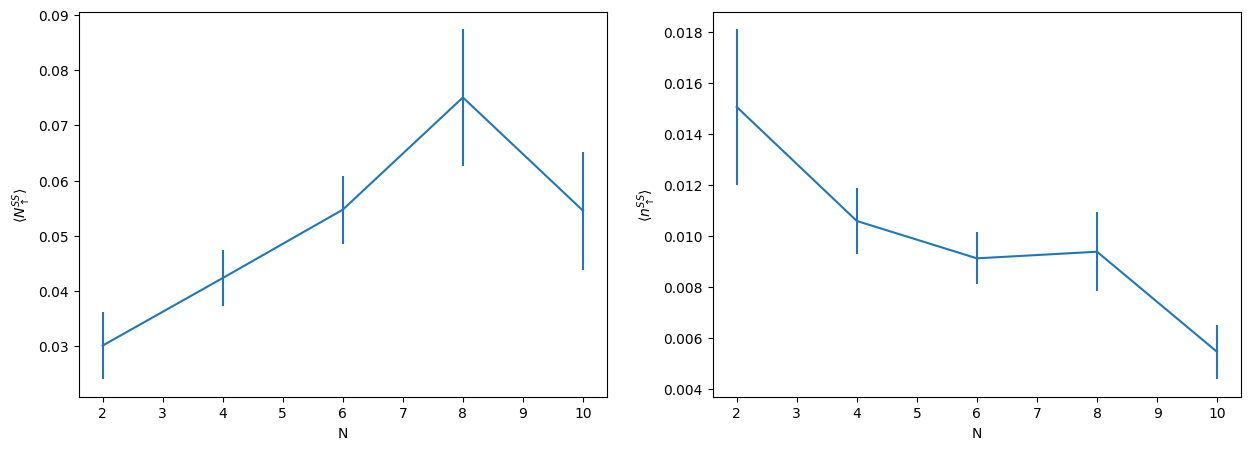

In [5]:
mean_SS = mean.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i])] for i = 1:length(popup_t_N)])
std_SS = std.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i])] for i = 1:length(popup_t_N)])

fig, axes = subplots(1, 2, figsize = (15, 5))
axes[1].errorbar(N_list, mean_SS, yerr=std_SS ./ sqrt.([length(popup_t_N[i])-length(nbr_error_t_N[i]) for i = 1:length(N_list)]))
axes[1].set_xlabel("N")
axes[1].set_ylabel(L"$\langle  N_{\uparrow}^{SS} \rangle $")

axes[2].errorbar(N_list, mean_SS./N_list, yerr=std_SS ./ (N_list .* sqrt.([length(popup_t_N[i])-length(nbr_error_t_N[i]) for i = 1:length(N_list)])))
axes[2].set_xlabel("N")
axes[2].set_ylabel(L"$\langle  n_{\uparrow}^{SS} \rangle $")

pygui(false); gcf();
# pygui(true); show()

# Plot the evolutions that didn't work

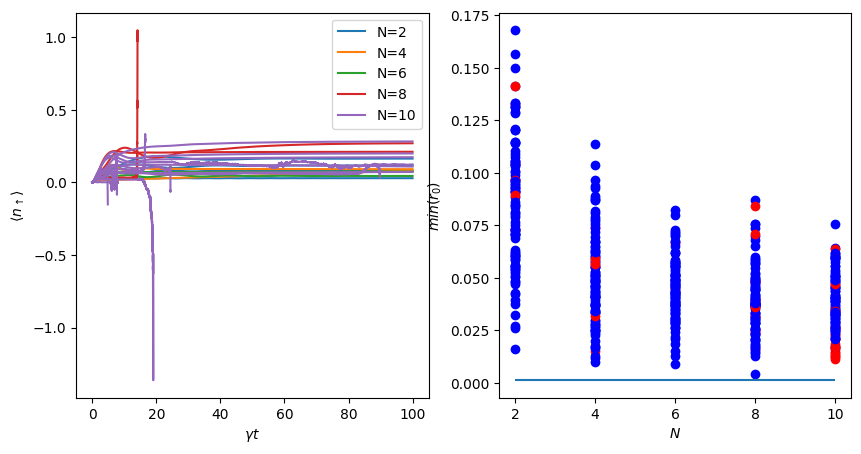

In [6]:
close("all")
fig, axes = subplots(1, 2, figsize=(10, 5))
for i in 1:length(popup_t_N)
    line = []
    for j in 1:length(popup_t_N[i])
        @load "r0/r0_N_$(N_list[i])_r_$j.jdl2" r0 L
        if j ∈ nbr_error_t_N[i]
            if line == []
                line, = axes[1].plot(list_t_N[i][j], popup_t_N[i][j], label="N=$(N_list[i])")
            else
                axes[1].plot(list_t_N[i][j], popup_t_N[i][j], color=line.get_color())
            end
            axes[2].scatter(N_list[i], min_r0(r0), color ="r")
        else
            axes[2].scatter(N_list[i], min_r0(r0), color ="b")
        end
    end
end

axes[2].hlines(d0_lb, N_list[1], N_list[end])
axes[1].set_xlabel(L"$\gamma t$")
axes[1].set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
axes[2].set_xlabel(L"N")
axes[2].set_ylabel(L"min(r_0)")
axes[1].legend()
pygui(false); gcf();
# pygui(true); show()

# Timestep 

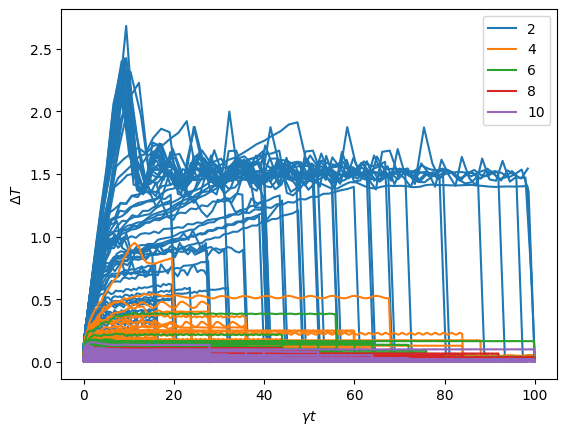

In [7]:
close("all")
fig, ax = subplots()
for i in 1:length(popup_t_N)
    line = []
    for j in 1:length(popup_t_N[i])
        T = list_t_N[i][j]
        if j == 1
            line, = ax.plot(T[1:end-1], T[2:end]-T[1:end-1], label=N_list[i])
        else
            ax.plot(T[1:end-1], T[2:end]-T[1:end-1], color=line.get_color())
        end
    end
end


ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\Delta T$")
ax.legend()
pygui(false); gcf();
# pygui(true); show()

# Plot condition evolution

In [8]:
function stop_condition(popup, T)
    popup_smooth = runmean_window_t(popup, T, window_t)
    boxes = boxmean_window_t(popup_smooth, T[T .> window_var], window_var)
    Delta_boxes = boxes[2:end] - boxes[1:end-1]
    T_boxes = [i*window_var for i in 1:length(Delta_boxes)]
    return Delta_boxes, T_boxes
end

stop_condition (generic function with 1 method)

<sys>:0: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


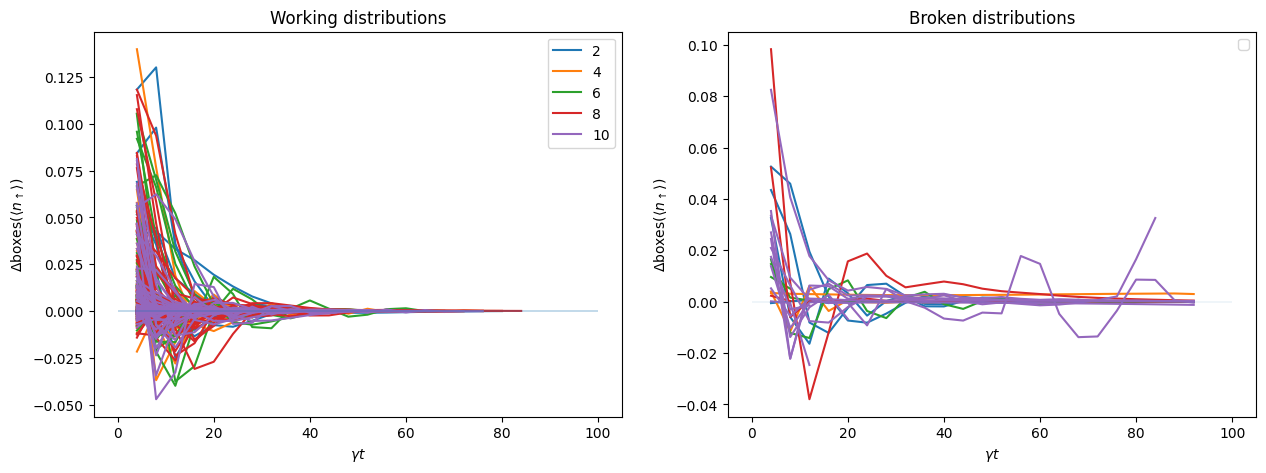

In [9]:
close("all")
fig, axes = subplots(1, 2, figsize=(15, 5))
max_t = 0

for i in 1:length(popup_t_N)
    line = []
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            Delta_boxes, T_boxes = stop_condition(popup_t_N[i][j], list_t_N[i][j])

            if line == []
                line, = axes[1].plot(T_boxes,Delta_boxes, label=N_list[i])
            else
                axes[1].plot(T_boxes, Delta_boxes, color=line.get_color())
            end
            if T_boxes[end] > max_t
                max_t = T_boxes[end]
            end
        else
            if list_t_N[i][j][end] > 2*window_var
                Delta_boxes, T_boxes = stop_condition(popup_t_N[i][j], list_t_N[i][j])
                if line == []
                    line, = axes[2].plot(T_boxes,Delta_boxes, label=N_list[i])
                else
                    axes[2].plot(T_boxes, Delta_boxes, color=line.get_color())
                end
            end
        end
    end
end

axes[1].hlines(threshold_box, 0, maximum([maximum([T[end] for T in list_t]) for list_t in list_t_N]), linewidth=0.2), axes[1].hlines(-threshold_box, 0, maximum([maximum([T[end] for T in list_t]) for list_t in list_t_N]), linewidth=0.2)
axes[2].hlines(threshold_box, 0, maximum([maximum([T[end] for T in list_t]) for list_t in list_t_N]), linewidth=0.1)#, axes[2, 2].hlines(-threshold_box_deriv, 0, t_end, linewidth=0.1)


axes[1].set_xlabel(L"$\gamma t$")
axes[1].set_ylabel(L"$\Delta $boxes($\langle  n_{\uparrow} \rangle $)")
axes[1].legend()
axes[1].title.set_text("Working distributions")

axes[2].set_xlabel(L"$\gamma t$")
axes[2].set_ylabel(L"$\Delta $boxes($\langle  n_{\uparrow} \rangle $)")
axes[2].legend()
axes[2].title.set_text("Broken distributions")

pygui(false); gcf();
# pygui(true); show()


# Evolution of individual atoms

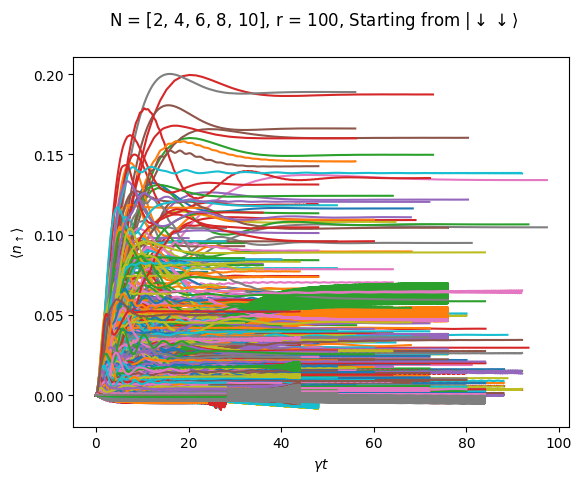

In [10]:
close("all")
fig, ax = subplots()

for (i, N) = enumerate(N_list)
    line = []
    @load "solutions/sol_N_$(N)_r_$(r).jld2" sol_tasks
    list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    for j = 1:r
        if j ∉ nbr_error_t_N[i]
            # ax.plot(list_t[j], popup_t[j], label="Sum")
            for n in 1:N
                ax.plot(list_t[j], real([sol_t[j][t][n] for t in 1:length(list_t[j])]), label="$n")
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle n_{\uparrow} \rangle $")
# ax.set_ylim(-0.002, 0.005)
# ax.legend()

suptitle("N = $N_list, r = $r, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

# Comparison with spontaneous emission

In [92]:
function deriv_indep_atoms(du, u, p, t)
    γ, Ω = p[1], p[2]
    du[1] = -2γ*u[1] + 1im*Ω*(u[2]-conj(u[2])) # u[1] = ρee, u[2] = ρeg
    du[2] = -γ*u[2] + 1im*Ω*(2*u[1]-1)
end

deriv_indep_atoms (generic function with 1 method)

In [93]:
u0_indep = zeros(ComplexF64, 2)
prob = ODEProblem(deriv_indep_atoms, u0_indep, (0, t_end), [γ, Ω_RO])
sol_indep = solve(prob);

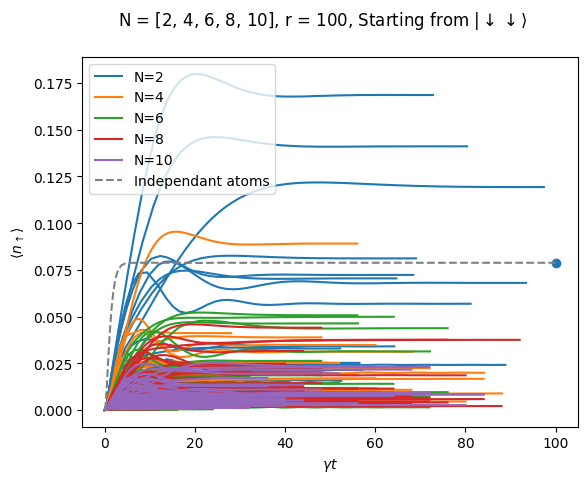

In [94]:
close("all")
fig, ax = subplots()

for (i, N) in enumerate(N_list)
    line = []
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] ./ N_list[i], label="N=$(N_list[i])") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t_N[i][j], popup_t_N[i][j] ./ N_list[i], color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

plot(sol_indep.t, real([sol[1] for sol in sol_indep.u]), linestyle="--", color="grey", label="Independant atoms")
scatter(t_end, 1/(2+(γ/Ω_RO)^2))

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N_list, r = $r, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

# Fit the independant case to the SS interacting case

In [95]:
function fit_γ_SE(n_up_SS, Ω)
    return Ω*sqrt(1/n_up_SS - 2)
end

fit_γ_SE (generic function with 1 method)

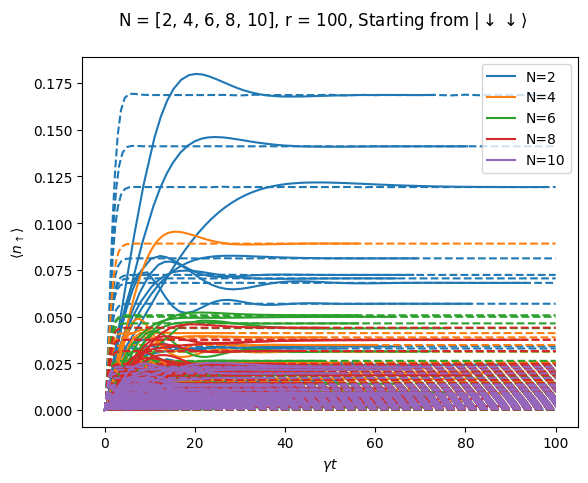

In [96]:
close("all")
fig, ax = subplots()

u0_indep = zeros(ComplexF64, 2)
decay_rate_interactions_eq_indep = zeros((length(N_list), r))


for (i, N) in enumerate(N_list)
    line = []
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] ./ N_list[i], label="N=$(N_list[i])") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t_N[i][j], popup_t_N[i][j] ./ N_list[i], color=line.get_color()) # marker="o", markersize=1,
            end

            γ_fit_SE = fit_γ_SE(popup_t_N[i][j][end]/N_list[i], Ω_RO)
            prob = ODEProblem(deriv_indep_atoms, u0_indep, (0, t_end), [γ_fit_SE, Ω_RO])
            sol_indep = solve(prob)
            plot(sol_indep.t, real([sol[1] for sol in sol_indep.u]), linestyle="--", color=line.get_color())

            decay_rate_interactions_eq_indep[i, j] = γ_fit_SE
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N_list, r = $r, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

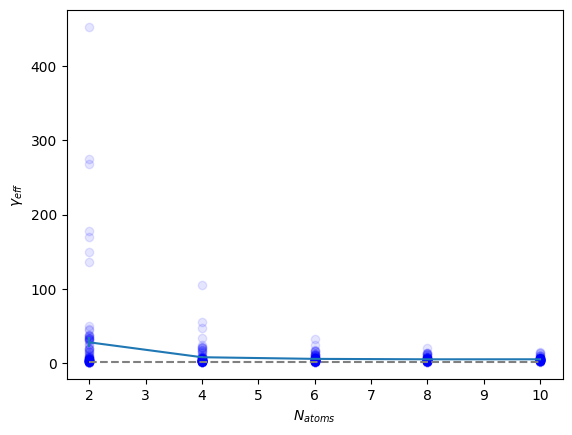

In [97]:
close("all")
fig = subplots()

errorbar(N_list, [mean(decay_rate_interactions_eq_indep[i, :][decay_rate_interactions_eq_indep[i, :] .> 0]) for i in 1:size(decay_rate_interactions_eq_indep)[1]], yerr=[std(decay_rate_interactions_eq_indep[i, :][decay_rate_interactions_eq_indep[i, :] .> 0])/sqrt(r) for i in 1:size(decay_rate_interactions_eq_indep)[1]])

for i in 1:length(N_list)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(N_list[i], decay_rate_interactions_eq_indep[i, j], color="blue", alpha=0.1)
        end
    end
end
 
xlabel(L"N_{atoms}")
ylabel(L"\gamma_{eff}")

hlines(1, N_list[1], N_list[end], linestyle="--", color="grey")
# ylim(0, 1.5)
# pygui(true); show()
pygui(false);

### Weighted equivalent independant decay rate

In [98]:
decay_rate_interactions_eq_indep_weighted = zeros(ComplexF64, (length(N_list), r))

for (i, N) in enumerate(N_list)
    @load "op_list/op_list_$N.jdl2" op_list
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            sol_SS = sol_t_N[i][j][end]

            decay_rate_interactions_eq_indep_weighted[i, j] += 2*decay_rate_interactions_eq_indep[i, j]*sum(sol_SS[a] for a = 1:N)
            decay_rate_interactions_eq_indep_weighted[i, j] -= 2*Ω_RO*sum([imag(sol_SS[a]) for a = N+1:2*N])

        end
    end
end
decay_rate_interactions_eq_indep_weighted

5×100 Matrix{ComplexF64}:
 0.0174255+0.0im          0.0240049+0.0im          …  0.0861462+0.0im
 0.0447885+3.06162e-19im   0.277412+1.7094e-18im      0.0495245-4.11939e-18im
  0.397934+1.45542e-18im   0.554953+1.90685e-18im      0.234892+7.98632e-18im
 0.0439497-2.07548e-18im    0.26157-1.81088e-18im     0.0656497+9.773e-18im
  0.200964+1.15335e-17im   0.608371+8.71349e-18im      0.305046-3.20489e-19im

In [99]:
decay_rate_interactions_eq_indep_weighted = real.(decay_rate_interactions_eq_indep_weighted)

5×100 Matrix{Float64}:
 0.0174255  0.0240049  0.0254003  …  0.0184304  0.0130619   0.0861462
 0.0447885  0.277412   0.35359       0.0        0.00870119  0.0495245
 0.397934   0.554953   0.253386      0.0999318  0.263294    0.234892
 0.0439497  0.26157    0.337048      0.073768   0.400739    0.0656497
 0.200964   0.608371   0.242104      0.177049   0.125741    0.305046

### Weighted corresponding independant decay rate

In [100]:
decay_rate_independant_eq_indep_weighted = zeros(ComplexF64, (length(N_list), r))

for (i, N) in enumerate(N_list)
    @load "op_list/op_list_$N.jdl2" op_list
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            sol_SS = sol_t_N[i][j][end]

            decay_rate_independant_eq_indep_weighted[i, j] += 2*γ*sum(sol_SS[a] for a = 1:N)
            decay_rate_independant_eq_indep_weighted[i, j] -= 2*Ω_RO*sum([imag(sol_SS[a]) for a = N+1:2*N])

        end
    end
end
decay_rate_independant_eq_indep_weighted

5×100 Matrix{ComplexF64}:
 -0.00599172+0.0im          …   0.00908635+0.0im
   0.0110131+1.45156e-20im      0.00614293-2.5479e-19im
    0.130194+7.35456e-19im       0.0355861+1.87145e-18im
   -0.129458-2.78784e-19im     -0.00346625+4.74675e-19im
  -0.0859787+2.20177e-18im        -0.04978-8.31222e-20im

In [101]:
decay_rate_independant_eq_indep_weighted = real.(decay_rate_independant_eq_indep_weighted)

5×100 Matrix{Float64}:
 -0.00599172  -0.0372042  -0.0582146   …   0.00332628   0.00908635
  0.0110131    0.100058    0.175287       -0.00462837   0.00614293
  0.130194     0.30203    -0.00200591      0.00668436   0.0355861
 -0.129458     0.0221443   0.093187        0.0953724   -0.00346625
 -0.0859787    0.181393    0.0593421      -0.11968     -0.04978

### Plots

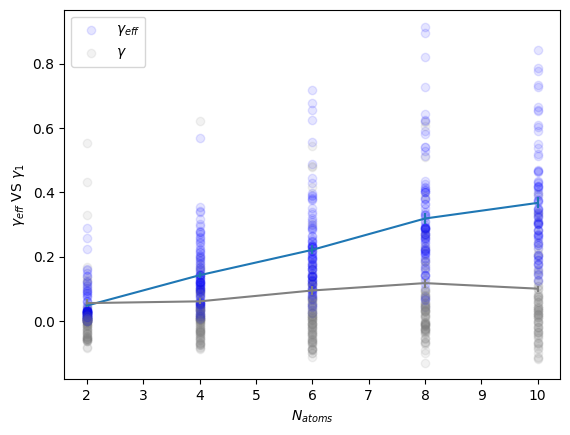

In [102]:
close("all")
fig = subplots()

errorbar(N_list, [mean(decay_rate_interactions_eq_indep_weighted[i, :][decay_rate_interactions_eq_indep_weighted[i, :] .> 0]) for i in 1:size(decay_rate_interactions_eq_indep_weighted)[1]], yerr=[std(decay_rate_interactions_eq_indep_weighted[i, :][decay_rate_interactions_eq_indep_weighted[i, :] .> 0])/sqrt(r) for i in 1:size(decay_rate_interactions_eq_indep_weighted)[1]])
errorbar(N_list, [mean(decay_rate_independant_eq_indep_weighted[i, :][decay_rate_independant_eq_indep_weighted[i, :] .> 0]) for i in 1:size(decay_rate_independant_eq_indep_weighted)[1]], yerr=[std(decay_rate_independant_eq_indep_weighted[i, :][decay_rate_independant_eq_indep_weighted[i, :] .> 0])/sqrt(r) for i in 1:size(decay_rate_independant_eq_indep_weighted)[1]], color="grey")

for i in 1:length(N_list)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(N_list[i], decay_rate_interactions_eq_indep_weighted[i, j], color="blue", alpha=0.1)
            scatter(N_list[i], decay_rate_independant_eq_indep_weighted[i, j], color="grey", alpha=0.1)
        end
    end
end

legend([L"\gamma_{eff}", L"γ"])
xlabel(L"N_{atoms}")
ylabel(L"$\gamma_{eff}$ VS $\gamma_1$")

# hlines(1, N_list[1], N_list[end], linestyle="--", color="grey")
# ylim(0, 1.5)
# pygui(true); show()
pygui(false);

# Compute a decay rate from the $\Gamma$ matrix

In [103]:
decay_rate_interactions_Gamma_matrix = zeros(ComplexF64, (length(N_list), r))

for (i, N) in enumerate(N_list)
    @load "op_list/op_list_$N.jdl2" op_list

    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            @load "r0/r0_N_$(N)_r_$j.jdl2" r0 L
            system = SpinCollection(r0, e, gammas=1.)
            Γ_CS = GammaMatrix(system)
            
            sol_SS = sol_t_N[i][j][end]

            for a = 1:N
                for b = 1:N
                    if a == b
                        decay_rate_interactions_Gamma_matrix[i, j] += Γ_CS[a, a]*sol_SS[a]
                    end
                    if b > a
                        corr = [21*10^(floor(Int, log10(a))+1)+a, 12*10^(floor(Int, log10(b))+1)+b]
                        # corr = [22*10^(floor(Int, log10(a))+1)+a, 22*10^(floor(Int, log10(b))+1)+b]
                        try
                            decay_rate_interactions_Gamma_matrix[i, j] += 2*Γ_CS[a, b]*sol_SS[findall(x->x==corr || x==reverse(corr), op_list)[1]]
                        catch
                            println("Error @ $N, r=$j, a=$a, b=$b, corr=$corr")
                        end
                    end
                end
            end
        end
    end
end
decay_rate_interactions_Gamma_matrix

5×100 Matrix{ComplexF64}:
 0.00152883+0.000246324im  …    0.0278202-0.00587587im
 0.00135111+0.000396383im     0.000786098+0.000102906im
  0.0813083-0.0131118im         0.0610286-0.00295706im
  0.0609778-0.000494584im      0.00368816+8.96747e-5im
    0.06028+0.0023955im         0.0891556-0.00804249im

In [104]:
decay_rate_interactions_Gamma_matrix = real.(decay_rate_interactions_Gamma_matrix)

5×100 Matrix{Float64}:
 0.00152883  0.0132783  0.0366319  0.046375   …  0.000231402  0.0278202
 0.00135111  0.0557997  0.0241276  0.0997944     0.000258191  0.000786098
 0.0813083   0.0814733  0.0931235  0.0824828     0.0797611    0.0610286
 0.0609778   0.0145462  0.0378501  0.0455594     0.0714426    0.00368816
 0.06028     0.0497618  0.0070732  0.0           0.0749457    0.0891556

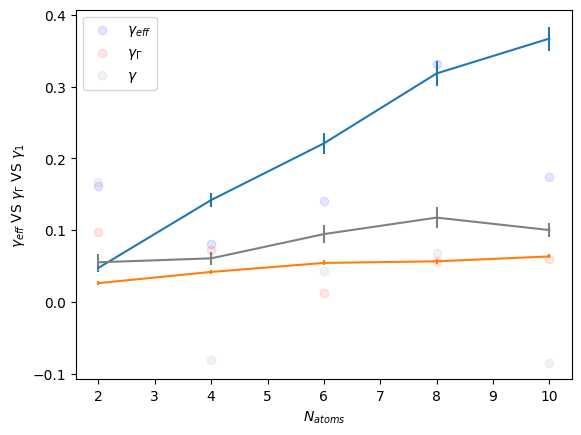

In [105]:
close("all")
fig = subplots()

errorbar(N_list, [mean(decay_rate_interactions_eq_indep_weighted[i, :][decay_rate_interactions_eq_indep_weighted[i, :] .> 0]) for i in 1:size(decay_rate_interactions_eq_indep_weighted)[1]], yerr=[std(decay_rate_interactions_eq_indep_weighted[i, :][decay_rate_interactions_eq_indep_weighted[i, :] .> 0])/sqrt(r) for i in 1:size(decay_rate_interactions_eq_indep_weighted)[1]])
errorbar(N_list, [mean(decay_rate_interactions_Gamma_matrix[i, :][decay_rate_interactions_Gamma_matrix[i, :] .> 0]) for i in 1:size(decay_rate_interactions_Gamma_matrix)[1]], yerr=[std(decay_rate_interactions_Gamma_matrix[i, :][decay_rate_interactions_Gamma_matrix[i, :] .> 0])/sqrt(r) for i in 1:size(decay_rate_interactions_Gamma_matrix)[1]])
errorbar(N_list, [mean(decay_rate_independant_eq_indep_weighted[i, :][decay_rate_independant_eq_indep_weighted[i, :] .> 0]) for i in 1:size(decay_rate_independant_eq_indep_weighted)[1]], yerr=[std(decay_rate_independant_eq_indep_weighted[i, :][decay_rate_independant_eq_indep_weighted[i, :] .> 0])/sqrt(r) for i in 1:size(decay_rate_independant_eq_indep_weighted)[1]], color="grey")


for i in 1:length(N_list)
    for j in [7]#1:10#r
        if j ∉ nbr_error_t_N[i]
            scatter(N_list[i], decay_rate_interactions_eq_indep_weighted[i, j], color="blue", alpha=0.1)
            scatter(N_list[i], decay_rate_interactions_Gamma_matrix[i, j], color="red", alpha=0.1)
            scatter(N_list[i], decay_rate_independant_eq_indep_weighted[i, j], color="grey", alpha=0.1)
        end
    end
end

legend([L"\gamma_{eff}", L"\gamma_\Gamma", L"γ"])

xlabel(L"N_{atoms}")
ylabel(L"$\gamma_{eff}$ VS $\gamma_\Gamma$ VS $\gamma_1$")
# pygui(true); show()
pygui(false);

### Weird cases

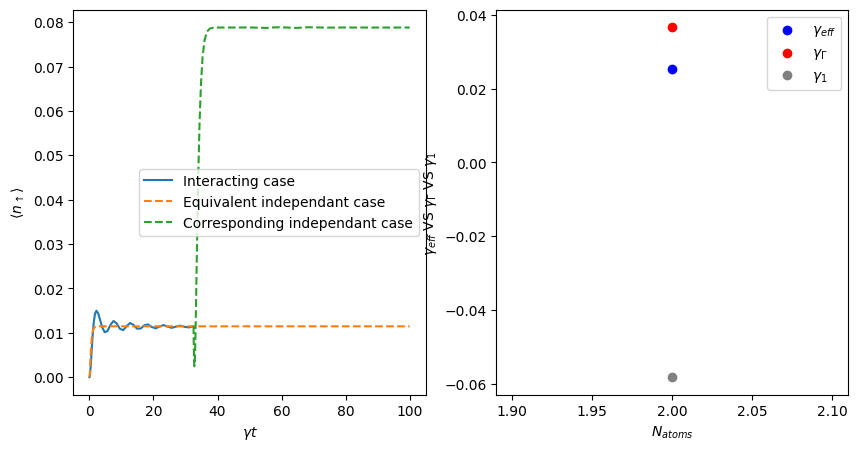

In [106]:
i = 1
j = 3

close("all")
fig, axs = subplots(1, 2, figsize=(10, 5))

axs[1].plot(list_t_N[i][j], popup_t_N[i][j] ./ N_list[i]) 

u0_indep = zeros(ComplexF64, 2)
γ_fit_SE = fit_γ_SE(popup_t_N[i][j][end]/N_list[i], Ω_RO)
prob = ODEProblem(deriv_indep_atoms, u0_indep, (0, t_end), [γ_fit_SE, Ω_RO])
sol_indep = solve(prob)

u0_gamma_1 = [popup_t_N[i][j][end]/N_list[i], sum(sol_t_N[i][j][end][N_list[i]+1:2*N_list[i]])/N_list[i]] #  u[1] = ρee, u[2] = ρeg
prob_gamma_1 = ODEProblem(deriv_indep_atoms, u0_gamma_1, (list_t_N[i][j][end], t_end), [γ, Ω_RO])
sol_indep_gamma_1 = solve(prob_gamma_1)

axs[1].plot(sol_indep.t, real([sol[1] for sol in sol_indep.u]), linestyle="--")
axs[1].plot(sol_indep_gamma_1.t, real([sol[1] for sol in sol_indep_gamma_1.u]), linestyle="--")
axs[1].set_xlabel(L"$\gamma t$")
axs[1].set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
axs[1].legend(["Interacting case", "Equivalent independant case", "Corresponding independant case"])

axs[2].scatter(N_list[i], decay_rate_interactions_eq_indep_weighted[i, j], color="blue")
axs[2].scatter(N_list[i], decay_rate_interactions_Gamma_matrix[i, j], color="red")
axs[2].scatter(N_list[i], decay_rate_independant_eq_indep_weighted[i, j], color="grey")

axs[2].set_xlabel(L"N_{atoms}")
axs[2].set_ylabel(L"$\gamma_{eff}$ VS $\gamma_\Gamma$ VS $\gamma_1$")
axs[2].legend([L"$\gamma_{eff}$", L"$\gamma_\Gamma$", L"$\gamma_1$"])
pygui(false); 
# pygui(true); show()

### Plot the derivatives

In [133]:
function compute_deriv_indep_atoms(u_t, p)
    du = zeros(ComplexF64, (length(u_t), 2))
    γ, Ω = p[1], p[2]
    for (i, u) in enumerate(u_t)
        du[i, 1] = -2γ * u[1] + 1im*Ω *(u[2] - conj(u[2])) # u[1] = ρee, u[2] = ρeg
        du[i, 2] = -γ * u[2] + 1im*Ω * (2 * u[1] - 1)
    end
    return du
end

compute_deriv_indep_atoms (generic function with 1 method)

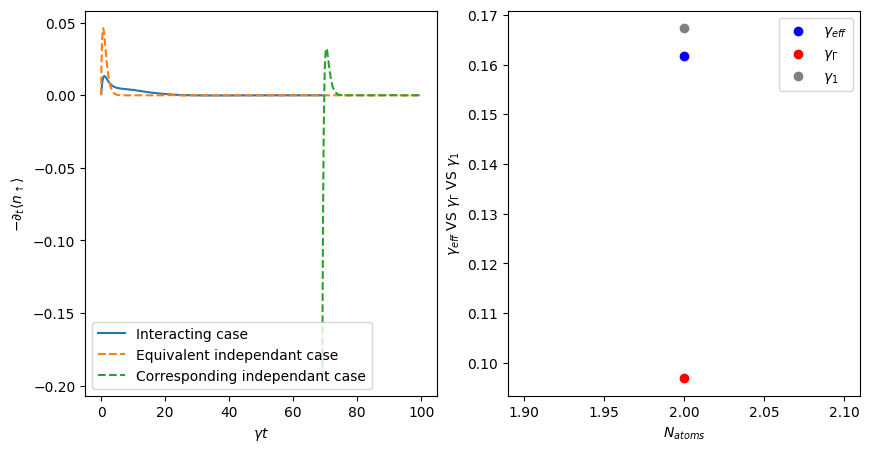

In [151]:
i = 1
j = 7

close("all")
fig, axs = subplots(1, 2, figsize=(10, 5))

axs[1].plot(list_t_N[i][j][2:end], (popup_t_N[i][j][2:end] - popup_t_N[i][j][1:end-1]) ./ (N_list[i] .* (list_t_N[i][j][2:end]-list_t_N[i][j][1:end-1]))) 

u0_indep = zeros(ComplexF64, 2)
γ_fit_SE = fit_γ_SE(popup_t_N[i][j][end]/N_list[i], Ω_RO)
prob = ODEProblem(deriv_indep_atoms, u0_indep, (0, t_end), [γ_fit_SE, Ω_RO])
sol_indep = solve(prob)

u0_gamma_1 = [popup_t_N[i][j][end]/N_list[i], sum(sol_t_N[i][j][end][N_list[i]+1:2*N_list[i]])/N_list[i]] #  u[1] = ρee, u[2] = ρeg
prob_gamma_1 = ODEProblem(deriv_indep_atoms, u0_gamma_1, (list_t_N[i][j][end], t_end), [γ, Ω_RO])
sol_indep_gamma_1 = solve(prob_gamma_1)

axs[1].plot(sol_indep.t[2:end], real.(compute_deriv_indep_atoms(sol_indep.u, [γ_fit_SE, Ω_RO])[:, 1])[2:end], linestyle="--")
axs[1].plot(sol_indep_gamma_1.t[2:end], real.(compute_deriv_indep_atoms(sol_indep_gamma_1.u, [γ, Ω_RO])[:, 1])[2:end], linestyle="--")


axs[1].set_xlabel(L"$\gamma t$")
axs[1].set_ylabel(L"$-\partial_t \langle  n_{\uparrow} \rangle $")
axs[1].legend(["Interacting case", "Equivalent independant case", "Corresponding independant case"])

axs[2].scatter(N_list[i], decay_rate_interactions_eq_indep_weighted[i, j], color="blue")
axs[2].scatter(N_list[i], decay_rate_interactions_Gamma_matrix[i, j], color="red")
axs[2].scatter(N_list[i], decay_rate_independant_eq_indep_weighted[i, j], color="grey")

axs[2].set_xlabel(L"N_{atoms}")
axs[2].set_ylabel(L"$\gamma_{eff}$ VS $\gamma_\Gamma$ VS $\gamma_1$")
axs[2].legend([L"$\gamma_{eff}$", L"$\gamma_\Gamma$", L"$\gamma_1$"])
pygui(false); 
# pygui(true); show()

# Brouillons

In [ ]:
# errorbar(N_list, vec(mean(decay_rate_interactions[decay_rate_interactions > 0], dims=2)), yerr=vec(std(decay_rate_interactions, dims=2)))

# decay_rate_interactions_Gamma_matrix = zeros(ComplexF64, (length(N_list), r))

# for (i, N) in enumerate(N_list[1:2])
#     @load "op_list/op_list_$N.jdl2" op_list

#     for j in 1:10
#         if j ∉ nbr_error_t_N[i]
#             @load "r0/r0_N_$(N)_r_$j.jdl2" r0 L
#             system = SpinCollection(r0, e, gammas=1.)
#             Γ_CS = GammaMatrix(system)
            
#             sol_SS = sol_t_N[i][j][end]

#             for a = 1:N
#                 for b = 1:N
#                     if a == b
#                         decay_rate_interactions_Gamma_matrix[i, j] += Γ_CS[a, a]*sol_SS[a]
#                     end
#                     if b < a
#                         corr = [22*10^(floor(Int, log10(a))+1)+a, 12*10^(floor(Int, log10(b))+1)+b]
#                         try
#                             decay_rate_interactions_Gamma_matrix[i, j] += 2*Γ_CS[a, b]*sol_SS[findall(x->x==corr || x==reverse(corr), op_list)[1]]

#                             # println(2*Γ_CS[a, b]*sol_SS[findall(x->x==corr || x==reverse(corr), op_list)[1]])
#                         catch
#                             println("Error @ $N, r=$j")
#                         end
#                     end
#                 end
#             end
#         end
#     end
# end